In [1]:
from src.dataset import DigitAnomalyDataset
from src.encoders import PCAAngleEncoder, AmplitudeEncoder
from src.feature_map import AngleFeatureMap, AmplitudeFeatureMap
from src.kernel import FidelityQuantumKernel, ClassicalRBFKernel
from src.models import OneClassSVMAnomalyModel
from src.anomaly_eval import AnomalyEvaluator
from src.visualizer import AnomalyVisualizer
from src.experiment import QuantumAnomalyExperiment
import pandas as pd

In [2]:
def run_all_four_methods(
    dataset,
    pca_components=4,
    reps=2,
    nu=0.1,
    threshold_strategy="expected_fraction",
    verbose=False,
    plot_best=False,
):
    """
    Run all 4 combinations:

        1. PCA encoder       + quantum angle kernel
        2. Amplitude encoder + quantum fidelity kernel
        3. PCA encoder       + classical RBF kernel
        4. Amplitude encoder + classical RBF kernel

    Returns
    -------
    comparison : pandas.DataFrame
        Summary table of metrics.

    results : dict
        Full result dictionaries for each method.

    experiments : dict
        Experiment objects, useful for plotting/debugging.
    """

    methods = {
        "PCA + Quantum Angle Kernel": {
            "encoder": PCAAngleEncoder(n_components=pca_components),
            "kernel": FidelityQuantumKernel(
                feature_map=AngleFeatureMap(reps=reps)
            ),
        },

        "Amplitude + Quantum Fidelity Kernel": {
            "encoder": AmplitudeEncoder(n_qubits=6),
            "kernel": FidelityQuantumKernel(
                feature_map=AmplitudeFeatureMap()
            ),
        },

        "PCA + Classical RBF Kernel": {
            "encoder": PCAAngleEncoder(n_components=pca_components),
            "kernel": ClassicalRBFKernel(gamma="scale"),
        },

        "Amplitude + Classical RBF Kernel": {
            "encoder": AmplitudeEncoder(n_qubits=6),
            "kernel": ClassicalRBFKernel(gamma="scale"),
        },
    }

    results = {}
    experiments = {}
    rows = []

    for method_name, components in methods.items():
        exp = QuantumAnomalyExperiment(
            name=method_name,
            dataset=dataset,
            encoder=components["encoder"],
            kernel=components["kernel"],
            model=OneClassSVMAnomalyModel(nu=nu),
            evaluator=AnomalyEvaluator(threshold_strategy=threshold_strategy),
            visualizer=AnomalyVisualizer(),
        )

        result = exp.run(verbose=verbose)

        results[method_name] = result
        experiments[method_name] = exp

        metrics = result["metrics"]
        encoder_info = result.get("encoder_info", {})
        kernel_info = result.get("kernel_info", {})

        row = {
            "method": method_name,
            "encoder": encoder_info.get("type", "unknown"),
            "kernel": kernel_info.get("type", "unknown"),
            "auc": metrics["auc"],
            "f1": metrics["f1"],
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "threshold": metrics["threshold"],
        }

        if encoder_info.get("type") == "pca_angle":
            row["encoded_dim"] = encoder_info.get("n_components")
            row["qubits_or_features"] = encoder_info.get("n_components")
            row["explained_variance"] = encoder_info.get("total_explained_variance")

        elif encoder_info.get("type") == "amplitude":
            row["encoded_dim"] = encoder_info.get("state_dim")
            row["qubits_or_features"] = encoder_info.get("n_qubits")
            row["explained_variance"] = None

        else:
            row["encoded_dim"] = None
            row["qubits_or_features"] = None
            row["explained_variance"] = None

        rows.append(row)

    comparison = pd.DataFrame(rows)
    comparison = comparison.sort_values("auc", ascending=False).reset_index(drop=True)

    print("\n===== Comparison Table =====")
    display(comparison)

    if plot_best:
        best_method = comparison.iloc[0]["method"]
        print(f"\nPlotting best method: {best_method}")
        experiments[best_method].plot_results()

    return comparison, results, experiments

In [3]:
dataset = DigitAnomalyDataset(
    normal_digit=0,
    anomaly_digits=[1, 2, 3, 4, 5, 6, 7, 8, 9],
    n_train_normal=10,
    n_test_normal=10,
    n_test_anomaly=10,
    random_state=7,
)

comparison, results, experiments = run_all_four_methods(
    dataset=dataset,
    pca_components=4,
    reps=2,
    nu=0.1,
    verbose=False,
    plot_best=False,
)

qiskit_runtime_service.__init__:WARNING:2026-06-02 11:39:08,132: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (on-prem), the available account instances are: Hackathon IQUCodeFest Juin 2026. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-02 11:39:08,487: Loading instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem
qiskit_runtime_service.backends:WARNING:2026-06-02 11:39:08,961: Using instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem


Selected backend: ibm_quebec


qiskit_runtime_service.__init__:WARNING:2026-06-02 11:39:14,440: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (on-prem), the available account instances are: Hackathon IQUCodeFest Juin 2026. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-02 11:39:14,716: Loading instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem
qiskit_runtime_service.backends:WARNING:2026-06-02 11:39:15,085: Using instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem


Selected backend: ibm_quebec


qiskit_runtime_service.__init__:WARNING:2026-06-02 11:39:20,963: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (on-prem), the available account instances are: Hackathon IQUCodeFest Juin 2026. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-02 11:39:21,081: Loading instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem
qiskit_runtime_service.backends:WARNING:2026-06-02 11:39:21,704: Using instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem


Selected backend: ibm_quebec


qiskit_runtime_service.__init__:WARNING:2026-06-02 11:39:33,704: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (on-prem), the available account instances are: Hackathon IQUCodeFest Juin 2026. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-02 11:39:34,023: Loading instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem
qiskit_runtime_service.backends:WARNING:2026-06-02 11:39:34,589: Using instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem


Selected backend: ibm_quebec

===== Comparison Table =====


/home/samuel/IQcodefest_Stagiaires/src/kernel.py:419: ComplexWarning: Casting complex values to real discards the imaginary part
  X_train = np.asarray(X_train, dtype=float)
/home/samuel/IQcodefest_Stagiaires/src/kernel.py:430: ComplexWarning: Casting complex values to real discards the imaginary part
  X_test = np.asarray(X_test, dtype=float)


,method,encoder,kernel,auc,f1,precision,recall,threshold,encoded_dim,qubits_or_features,explained_variance
0,Amplitude + Classical RBF Kernel,amplitude,classical_rbf_kernel,1.00,1.000000,1.0,1.0,0.165463,64,6,NaN
1,PCA + Classical RBF Kernel,pca_angle,classical_rbf_kernel,0.97,0.900000,0.9,0.9,0.072451,4,4,0.732615
2,Amplitude + Quantum Fidelity Kernel,amplitude,fidelity_quantum_kernel,0.50,0.666667,0.5,1.0,-0.000000,64,6,NaN
3,PCA + Quantum Angle Kernel,pca_angle,fidelity_quantum_kernel,0.50,0.666667,0.5,1.0,-0.000000,4,4,0.732615


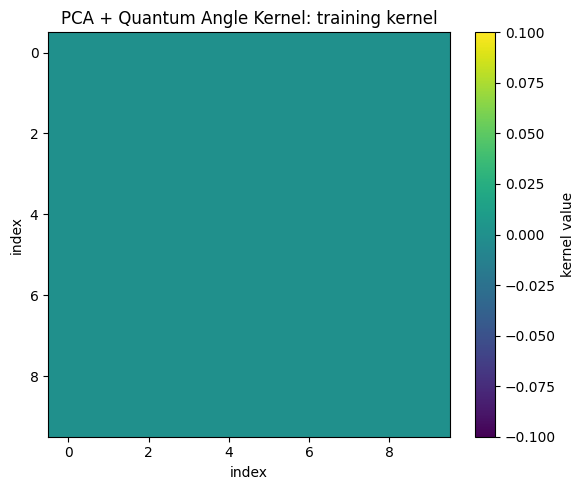

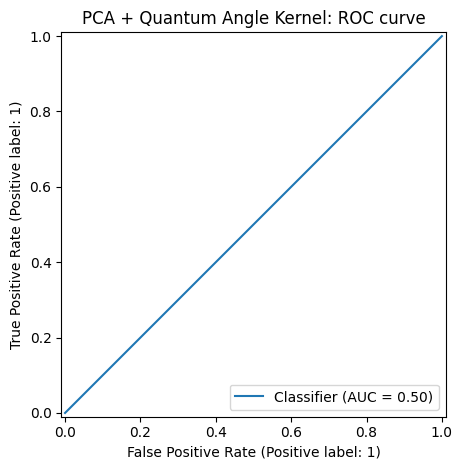

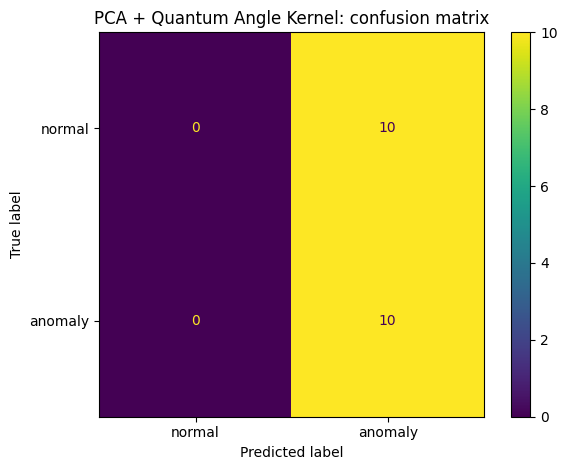

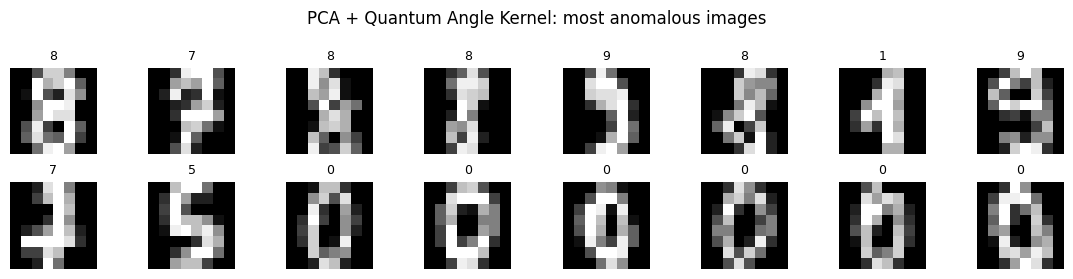

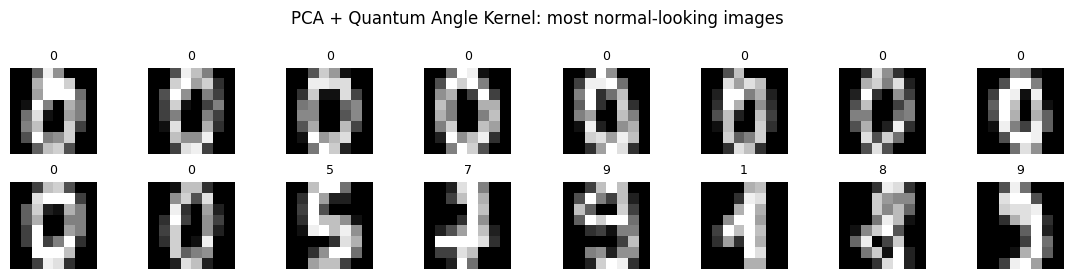

In [10]:
experiments["PCA + Quantum Angle Kernel"].plot_results()